In [12]:
import sys
import os
import importlib

parent = os.path.dirname(os.getcwd())
sys.path.insert(0, parent)

from Helpers import loadData, sphereMask, bipyramidMask, saveData, kernelPad
importlib.reload(sys.modules['Helpers'])
importlib.reload(sys.modules['Helpers.bipyramidMask'])
importlib.reload(sys.modules['Helpers'])

import math
import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.fft as fft
import torch.nn.functional as F
from scipy.ndimage import convolve
import stackview
from scipy.ndimage import zoom
from matplotlib.path import Path
from scipy.ndimage import rotate
import ipywidgets as widgets
from IPython.display import display

from sklearn.preprocessing import normalize
from skimage.feature import peak_local_max
from scipy.signal import fftconvolve
from skimage.feature import peak_local_max as pk

In [5]:
# Load downscaled data
name = 'pCycle2s3'
path = os.path.join(os.path.dirname(parent),'Data')
data = loadData(location=path, fileName=name+'.hdf5')

In [6]:
# Determine current device
device = torch.cuda.get_device_name()

if device == 'NVIDIA RTX A2000 12GB':
    client = 'Desktop'; cuts = 2
if device == 'NVIDIA RTX 4000 Ada Generation':
    client = 'Server';  cuts = 1

print(f'Identified {client}: {device}')

Identified Desktop: NVIDIA RTX A2000 12GB


In [7]:
# Display data dims
r,c,z = data.shape
print(f'Data dims: {r,c,z}')

# Crop to proper data dims
cropData = data[:,:928,:988]; r,c,z = cropData.shape
print(f'Data dims: {r,c,z}')

# Check size validity for server
if client == 'Server':
    if r % 2 == 1 and c % 2 == 1 and z % 4 == 0:
        print('Valid size')
    else:
        print('Requirements failed')
        raise TypeError

# Check size validity for desktop
elif client == 'Desktop':
    if r % 2 == 1 and c % 4 == 0 and z % 4 == 0:
        print('Valid size')
    else:
        print('Requirements failed')
        raise TypeError

Data dims: (803, 930, 990)
Data dims: (803, 928, 988)
Valid size


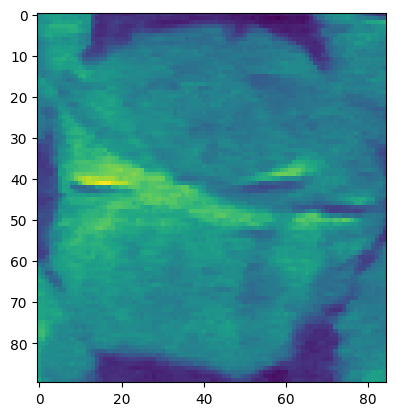

In [8]:
# Find a particle to base your kernel off of, adjust the cut manually
particle = cropData[445:535,80:165,195]
plt.imshow(particle);

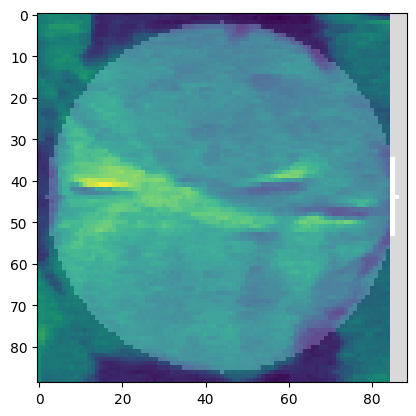

In [9]:
# Create sphere conv mask
kernel = sphereMask(diameter=140,pad=2,scale=.6)
kP = kernel.shape[0]//2+1

# Check for center point
assert kernel.shape[0] % 2 == 1, f'Kernel must be odd: {kernel.shape}'
assert kP % 2 == 1 ,             f'Kernel padding must be odd: kP={kP}'

# Visualize against particle
plt.imshow(particle)
plt.imshow(kernel[:,:,kernel.shape[2]//2], alpha=.15,cmap='grey');

In [13]:
# Create bipyramid conv mask
kernel = bipyramidMask(n=8, R=40, H=40, hr=5, pad=4,scale=1)
kP = kernel.shape[0]//2+1

# Check for center point
assert kernel.shape[0] % 2 == 1, f'Kernel must be odd: {kernel.shape}'
assert kP % 2 == 1 ,             f'Kernel padding must be odd: kP={kP}'

def showKernel(rot_z, rot_y, rot_x, alpha):
    # Rotate kernel
    k = kernel.copy()
    k = rotate(k, rot_z, axes=(0,1), reshape=False)  # rotate in r,c plane
    k = rotate(k, rot_y, axes=(0,2), reshape=False)  # rotate in r,z plane
    k = rotate(k, rot_x, axes=(1,2), reshape=False)  # rotate in c,z plane
    
    # Visualize center slice against particle
    plt.figure(figsize=(8,8))
    plt.imshow(particle)
    plt.imshow(k[:,:,k.shape[2]//2], alpha=alpha, cmap='grey')
    plt.show()

widgets.interact(
    showKernel,
    rot_z = widgets.IntSlider(min=-180, max=180, step=1, value=0,  description='Rot Z'),
    rot_y = widgets.IntSlider(min=-180, max=180, step=1, value=0,  description='Rot Y'),
    rot_x = widgets.IntSlider(min=-180, max=180, step=1, value=0,  description='Rot X'),
    alpha = widgets.FloatSlider(min=0, max=1, step=0.05, value=0.3, description='Alpha'),
);

interactive(children=(IntSlider(value=0, description='Rot Z', max=180, min=-180), IntSlider(value=0, descripti…